### run this notebook 

# Phase VI Part 3: biological function and pathway enrichment analysis 
+ In this notebook, genes that were identified via DEA after filtering for false discovery rate-adjusted P -value (0.05), and expression fold change (FC) exceeding a (commonly |logFC| >= 1). 

In [1]:
import gseapy as gp
import pandas as pd
import json

In [2]:
# Upload DEA result to further filter via logFC 
dea_df = pd.read_csv("../data/GSE252168/dea_filtered.tsv", sep="\t", usecols=[1,4])
print(dea_df.shape)
dea_df.head()

(14044, 2)


,Gene.symbol,logFC
0,TMEM261,0.478773
1,POLR2J4,0.654262
2,RPL9,1.555679
3,RPL31,1.620676
4,RPS15A,1.282546


In [71]:
print(f"Positive logFC: {(dea_df['logFC'] > 0).sum()}")
print(f"Negative logFC: {(dea_df['logFC'] < 0).sum()}")

Positive logFC: 6468
Negative logFC: 7576


In [72]:
print(f"Positive logFC (> 1): {(dea_df['logFC'] > 1).sum()}")
print(f"Negative logFC (< -1): {(dea_df['logFC'] < -1).sum()}")
print(f"Total |logFC| >= 1: {(dea_df['logFC'].abs() >= 1).sum()}")

Positive logFC (> 1): 30
Negative logFC (< -1): 3
Total |logFC| >= 1: 33


In [4]:
# Get only the genes with logGC is equal or higher than 1
dea_df = dea_df[dea_df['logFC'].abs() >= 1]

print(dea_df.shape)
dea_df.head()

(33, 2)


,Gene.symbol,logFC
2,RPL9,1.555679
3,RPL31,1.620676
4,RPS15A,1.282546
7,RPS17,1.144404
8,RPL27,1.151581


In [5]:
gene_list = list(dea_df["Gene.symbol"])
n = len(gene_list)

In [6]:
# Upload GO gmt file
go_set = "../data/enrichment/go.gmt"
kegg_set = "../data/enrichment/kegg.gmt"

In [7]:
# Upload the GO Terms and KEGG Term Mappings
kegg_map = open("../data/enrichment/kegg_mapping.json")
go_map = open(("../data/enrichment/go_mapping.json"))
kegg_terms_mapping = json.load(kegg_map)
go_term_mapping = json.load(go_map)

In [8]:
enr_go = gp.enrich(gene_list=gene_list, 
                 gene_sets=go_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-06 03:09:05,946 [INFO] User defined gene sets is given: ../data/enrichment/go.gmt
2026-03-06 03:09:06,045 [INFO] Run: go.gmt
2026-03-06 03:09:13,408 [INFO]   Background is not set! Use all 19591 genes in go.gmt.
2026-03-06 03:09:13,664 [INFO] Done.


In [9]:
enr_go.results.head()

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000028,1/24,0.027815,0.146111,55.448227,198.625201,RPS27
1,go.gmt,GO:0000118,1/87,0.097353,0.243613,15.015414,34.977064,HINT1
2,go.gmt,GO:0000122,1/1041,0.715362,0.777115,1.187154,0.397657,COMMD6
3,go.gmt,GO:0000244,1/49,0.056002,0.187145,26.832302,77.340724,SNRPG
4,go.gmt,GO:0000245,1/97,0.107944,0.256731,13.452504,29.947237,SNRPG


In [10]:
# Save the results to a new df
results_go = enr_go.results
print(results_go.shape)
results_go.head()

(528, 8)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,go.gmt,GO:0000028,1/24,0.027815,0.146111,55.448227,198.625201,RPS27
1,go.gmt,GO:0000118,1/87,0.097353,0.243613,15.015414,34.977064,HINT1
2,go.gmt,GO:0000122,1/1041,0.715362,0.777115,1.187154,0.397657,COMMD6
3,go.gmt,GO:0000244,1/49,0.056002,0.187145,26.832302,77.340724,SNRPG
4,go.gmt,GO:0000245,1/97,0.107944,0.256731,13.452504,29.947237,SNRPG


In [11]:
# Filter out results with less than 0.05 adjusted p value
results_go_filt = results_go[results_go['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_go_filt)}")
results_go_filt.head()

Number of significant results: 43


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
22,go.gmt,GO:0002181,12/177,2.515307e-19,4.426941e-17,127.436622,5457.692744,RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;RPS24;RPL...
54,go.gmt,GO:0003012,5/535,3.335878e-04,5.337404e-03,10.669358,85.414664,RPL27;RPL17;RPL39;RPL31;RPL9
58,go.gmt,GO:0003735,13/171,1.139238e-21,5.935110e-19,157.453357,7593.019251,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...
65,go.gmt,GO:0005198,13/855,1.453219e-12,1.096142e-10,28.577957,778.956225,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...
77,go.gmt,GO:0005730,9/1336,1.057209e-05,2.146948e-04,9.002883,103.148668,RSL24D1;RPL27;RPS27;RPS15A;RPS24;RPL26;RPS3A;R...


In [12]:
# Map GO terms id to descriptions
results_go_filt["GO Term Name"] = results_go_filt["Term"].map(go_term_mapping)

In [13]:
# Add new overlap column and calculate the overlap ratio
results_go_filt["new_overlap"] = results_go_filt["Overlap"].str.split("/").str[0] + "/30"
results_go_filt["new_overlap_rat"] = results_go_filt["Overlap"].apply(lambda x: int(x.split("/")[0]) / n)

# Reorder the df
results_go_filt = results_go_filt.iloc[:, [0, 1, 8, 9, 10,2,3,4,5,6,7]]

In [14]:
# Sort the results based on new overlap ratio
results_go_filt.sort_values("new_overlap_rat", ascending=False, inplace=True)

In [15]:
# Check the final df 
results_go_filt.head()

,Gene_set,Term,GO Term Name,new_overlap,new_overlap_rat,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
58,go.gmt,GO:0003735,structural constituent of ribosome,13/30,0.393939,13/171,1.139238e-21,5.935110e-19,157.453357,7593.019251,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...
91,go.gmt,GO:0006412,translation,13/30,0.393939,13/766,3.598446e-13,3.166633e-11,32.105318,919.917017,RPL27;RPL17;RPS29;EEF1B2;RPS27;RPS15A;RPL39;RP...
65,go.gmt,GO:0005198,structural molecule activity,13/30,0.393939,13/855,1.453219e-12,1.096142e-10,28.577957,778.956225,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...
519,go.gmt,GO:1990904,ribonucleoprotein complex,13/30,0.393939,13/1144,5.676633e-11,2.997262e-09,20.950382,494.263037,RPL27;RPL17;RPS29;SNRPG;RPS27;RPS15A;RPL39;RPS...
82,go.gmt,GO:0005840,ribosome,12/30,0.363636,12/236,8.482757e-18,8.957792e-16,93.659824,3681.626818,RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;RPS24;RPL...


In [16]:
# # Save GO encrichment analysis results
# results_go_filt.to_csv("../data/enrichment/dice_v2_go_results.tsv", sep="\t", index=False)

### Part 2: KEGG pathway enrichment analysis

In [17]:
enr_kegg = gp.enrich(gene_list=gene_list, 
                 gene_sets=kegg_set, 
                 background=None,
                 outdir=None,
                 verbose=True)

2026-03-06 03:09:13,820 [INFO] User defined gene sets is given: ../data/enrichment/kegg.gmt
2026-03-06 03:09:13,824 [INFO] Run: kegg.gmt
2026-03-06 03:09:13,846 [INFO]   Background is not set! Use all 8011 genes in kegg.gmt.
2026-03-06 03:09:13,859 [INFO] Done.


In [18]:
# Save the results to a new df
results_kegg = enr_kegg.results
print(results_kegg.shape)
results_kegg.head()

(30, 8)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
0,kegg.gmt,hsa00190,1/133,2.727246e-01,4.504693e-01,4.810097,6.249724,COX7C
1,kegg.gmt,hsa01100,1/1487,9.798813e-01,9.798813e-01,0.354897,0.007213,COX7C
2,kegg.gmt,hsa01522,1/96,2.049271e-01,4.504693e-01,6.705108,10.628274,MMP9
3,kegg.gmt,hsa03010,13/158,1.018115e-18,3.054344e-17,112.018239,4640.756511,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...
4,kegg.gmt,hsa03040,1/149,3.003129e-01,4.504693e-01,4.283101,5.152273,SNRPG


In [19]:
# Filter out results with less than 0.05 adjusted p value
results_kegg_filt = results_kegg[results_kegg['Adjusted P-value'] < 0.05].copy()
print(f"Number of significant results: {len(results_kegg_filt)}")
results_kegg_filt.head()

Number of significant results: 1


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
3,kegg.gmt,hsa03010,13/158,1.018115e-18,3.054344e-17,112.018239,4640.756511,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...


In [20]:
# Map GO terms id to descriptions
results_kegg_filt["KEGG Pathway"] = results_kegg_filt["Term"].map(kegg_terms_mapping)

In [21]:
# Add new overlap column and calculate the overlap ratio
results_kegg_filt["new_overlap"] = results_kegg_filt["Overlap"].str.split("/").str[0] + "/30"
results_kegg_filt["new_overlap_rat"] = results_kegg_filt["Overlap"].apply(lambda x: int(x.split("/")[0]) / n)

# Reorder the df
results_kegg_filt = results_kegg_filt.iloc[:, [0, 1, 8, 9, 10,2,3,4,5,6,7]]

In [22]:
# Sort the results based on new overlap ratio
results_kegg_filt.sort_values("new_overlap_rat", ascending=False, inplace=True)

In [23]:
# Check the final df
results_kegg_filt.head()

,Gene_set,Term,KEGG Pathway,new_overlap,new_overlap_rat,Overlap,P-value,Adjusted P-value,Odds Ratio,Combined Score,Genes
3,kegg.gmt,hsa03010,Ribosome - Homo sapiens (human),13/30,0.393939,13/158,1.018115e-18,3.054344e-17,112.018239,4640.756511,RSL24D1;RPL27;RPL17;RPS29;RPS27;RPS15A;RPL39;R...


In [24]:
# # Save the kegg encrichment results
# results_kegg_filt.to_csv("../data/enrichment/dice_v2_kegg_results.tsv", sep="\t", index=False)

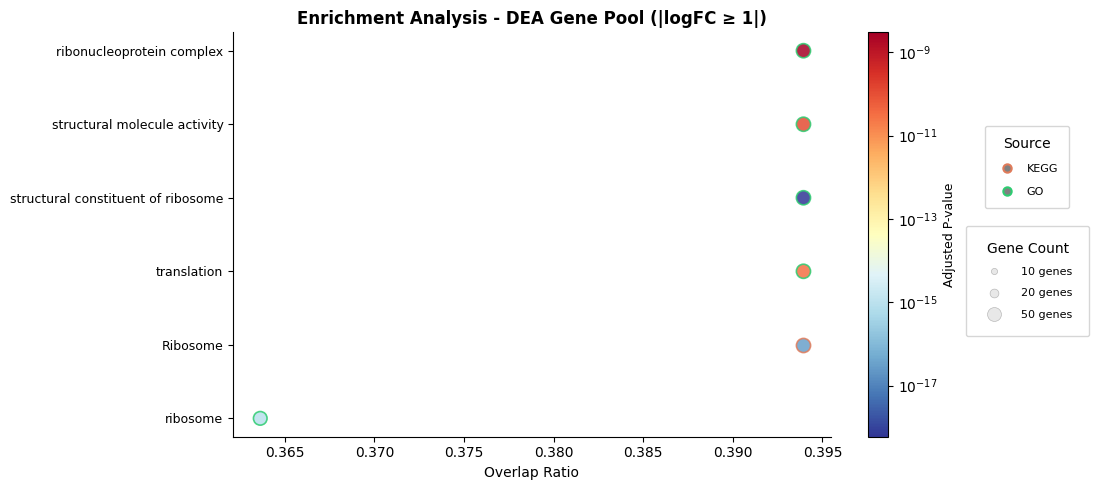

In [29]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
import numpy as np

# prep KEGG
top_kegg = results_kegg_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_kegg['KEGG Pathway'] = top_kegg['KEGG Pathway'].str.replace(' - Homo sapiens (human)', '', regex=False)
top_kegg['label'] = top_kegg['KEGG Pathway']
top_kegg['source'] = 'KEGG'

# prep GO
top_go = results_go_filt.sort_values('new_overlap_rat', ascending=False).head(5).copy()
top_go['label'] = top_go['GO Term Name']
top_go['source'] = 'GO'

# join
combined = pd.concat([top_kegg, top_go], ignore_index=True)
combined = combined.sort_values('new_overlap_rat', ascending=True).reset_index(drop=True)

source_colors = {'KEGG': '#e07b5a', 'GO': '#2ecc71'}

norm = LogNorm(vmin=combined['Adjusted P-value'].min(),
               vmax=combined['Adjusted P-value'].max())

fig, ax = plt.subplots(figsize=(10, 5))

for source, group in combined.groupby('source'):
    idx = group.index
    gc = group['Overlap'].apply(lambda x: int(x.split('/')[0]))
    ax.scatter(
        group['new_overlap_rat'], idx,
        s=gc * 8,
        c=group['Adjusted P-value'],
        cmap='RdYlBu_r',
        norm=norm,
        edgecolors=source_colors[source],
        linewidth=1.2,
        alpha=0.85,
        label=source
    )

ax.set_yticks(range(len(combined)))
ax.set_yticklabels(combined['label'], fontsize=9)
ax.set_xlabel('Overlap Ratio', fontsize=10)
ax.set_title('Enrichment Analysis - DEA Gene Pool (|logFC ≥ 1|)', fontsize=12, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='RdYlBu_r', norm=norm)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Adjusted P-value', fontsize=9)

# source legend handles
source_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#e07b5a', markeredgewidth=1.5,
           markersize=6, label='KEGG'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey',
           markeredgecolor='#2ecc71', markeredgewidth=1.5,
           markersize=6, label='GO')
]

# size legend handles
size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgrey',
           markeredgecolor='grey', markeredgewidth=0.5, alpha=0.5,
           markersize=np.sqrt(size*2), label=f'{size} genes')
    for size in [10, 20, 50]
]

legend1 = fig.legend(handles=source_handles, title='Source',
                     bbox_to_anchor=(1.08, 0.75), fontsize=8,
                     frameon=True, labelspacing=1.2, borderpad=1)

legend2 = fig.legend(handles=size_handles, title='Gene Count',
                     bbox_to_anchor=(1.1, 0.55), fontsize=8,
                     frameon=True, labelspacing=1,
                     borderpad=1.5, handletextpad=1.5)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('enrichment_dotplot_dea_fc_filt.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
combined["Adjusted P-value"]

0    8.957792e-16
1    3.054344e-17
2    3.166633e-11
3    5.935110e-19
4    1.096142e-10
5    2.997262e-09
Name: Adjusted P-value, dtype: float64